# TARDIS — Modèle prédictif du retard à l'arrivée

Objectif : **prédire la durée moyenne du retard à l'arrivée** (en minutes, variable continue)
pour un trajet donné, à partir de caractéristiques disponibles **avant le départ**.

**Cible :** `Average delay of all trains at arrival`

**Méthode :**
1. Charger `cleaned_dataset.csv`
2. Construire un pipeline de pré-traitement *safe* (pas de fuite de cible)
3. Entraîner et comparer 3 modèles : baseline, régression linéaire régularisée, Gradient Boosting
4. Tuner le meilleur modèle (GridSearchCV)
5. Analyser l'importance des features
6. Sauvegarder le modèle final (`model.joblib`) pour intégration au dashboard


In [1]:
from __future__ import annotations

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = Path("cleaned_dataset.csv")
MODEL_PATH = Path("model.joblib")
RANDOM_STATE = 42


## 1. Chargement du dataset nettoyé

In [2]:
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
print(f"Shape : {df.shape}")
df.head(3)


Shape : (11029, 36)


,Departure station,Arrival station,Date,Service,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Season,IsPeakMonth,IsWorksMonth,Route,IsParisDeparture,IsParisArrival,CancellationRate,DepartureDelayRate,SevereDelayRate,DelayCategory
0,AIX EN PROVENCE TGV,PARIS LYON,2018-01-01,National,188.0,402.0,0.0,117.0,6.625641,2.005431,...,Winter,0,0,AIX EN PROVENCE TGV → PARIS LYON,0,1,0.000000,0.291045,0.017413,Slight (0-5m)
1,AIX EN PROVENCE TGV,PARIS LYON,2018-02-01,National,188.0,356.0,0.0,143.0,7.292308,2.998502,...,Winter,0,0,AIX EN PROVENCE TGV → PARIS LYON,0,1,0.000000,0.401685,0.008427,Moderate (5-15m)
2,AIX EN PROVENCE TGV,PARIS LYON,2018-03-01,National,188.0,396.0,8.0,148.0,7.855518,3.070000,...,Spring,0,0,AIX EN PROVENCE TGV → PARIS LYON,0,1,0.020202,0.373737,0.007576,Slight (0-5m)


## 2. Sélection des features

> **Précaution anti-fuite :** on exclut toutes les variables qui mesurent *directement ou
> indirectement* le retard observé (retards au départ, nombres de trains en retard,
> pourcentages de causes) — ces variables ne sont pas connues avant le voyage et
> leur inclusion donnerait un R² artificiellement parfait.

**Features retenues (disponibles avant le départ) :**

| Type | Colonnes |
|---|---|
| Catégorielles | Departure station, Arrival station, Service, Season |
| Numériques | Year, Month, Quarter, Average journey time, Number of scheduled trains, IsPeakMonth, IsParisDeparture, IsParisArrival |


In [3]:
TARGET = "Average delay of all trains at arrival"

# Encodage cyclique du mois : (sin, cos) pour que décembre (12) et janvier (1)
# soient proches dans l'espace de features — indispensable pour Ridge, utile pour les arbres.
df["MonthSin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["MonthCos"] = np.cos(2 * np.pi * df["Month"] / 12)

CATEGORICAL_FEATURES = ["Departure station", "Arrival station", "Service", "Season"]
# Continues : on les scale (utile pour Ridge, neutre pour les arbres).
CONTINUOUS_FEATURES = [
    "Year",
    "Average journey time",
    "Number of scheduled trains",
    "MonthSin",
    "MonthCos",
]
# Binaires : ne PAS scaler (cela dégrade l'interprétabilité sans rien améliorer).
BINARY_FEATURES = [
    "IsPeakMonth",
    "IsWorksMonth",
    "IsParisDeparture",
    "IsParisArrival",
]

FEATURES = CATEGORICAL_FEATURES + CONTINUOUS_FEATURES + BINARY_FEATURES
X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Cible : moyenne {y.mean():.2f} min, écart-type {y.std():.2f} min")


X shape : (11029, 13)
y shape : (11029,)
Cible : moyenne 6.19 min, écart-type 4.25 min


## 3. Split train / test — **temporel par date**

> Un split aléatoire fuit l'information temporelle. Un split par **rang d'index**
> (`iloc[:0.8*N]`) coupe parfois **au milieu d'un mois** : plusieurs trajets du même
> mois se retrouvent moitié train / moitié test, ce qui injecte de l'information
> future dans le train.
>
> On splitte donc par **date** : tout ce qui est strictement avant `cutoff` va en
> train, le reste en test. Cible : ~80 / 20.

In [4]:
df_sorted = df.sort_values("Date").reset_index(drop=True)

CUTOFF = pd.Timestamp("2024-06-01")  # ~80/20 sur ce dataset, aligné sur un début de mois

train_mask = df_sorted["Date"] < CUTOFF
test_mask = df_sorted["Date"] >= CUTOFF

X_train = df_sorted.loc[train_mask, FEATURES].copy()
X_test = df_sorted.loc[test_mask, FEATURES].copy()
y_train = df_sorted.loc[train_mask, TARGET].copy()
y_test = df_sorted.loc[test_mask, TARGET].copy()

train_dates = df_sorted.loc[train_mask, "Date"]
test_dates = df_sorted.loc[test_mask, "Date"]

assert train_dates.max() < test_dates.min(), "leak: train/test overlap on date"

print(f"Cutoff : {CUTOFF:%Y-%m}")
print(f"Train : {len(X_train):,} trajets-mois  ({train_dates.min():%Y-%m} → {train_dates.max():%Y-%m})  {len(X_train)/len(df_sorted):.1%}")
print(f"Test  : {len(X_test):,} trajets-mois  ({test_dates.min():%Y-%m} → {test_dates.max():%Y-%m})  {len(X_test)/len(df_sorted):.1%}")
print(f"Cible train : moyenne {y_train.mean():.2f} min, écart-type {y_train.std():.2f} min")
print(f"Cible test  : moyenne {y_test.mean():.2f} min, écart-type {y_test.std():.2f} min")


Cutoff : 2024-06
Train : 8,827 trajets-mois  (2018-01 → 2024-05)  80.0%
Test  : 2,202 trajets-mois  (2024-06 → 2025-12)  20.0%
Cible train : moyenne 5.98 min, écart-type 4.26 min
Cible test  : moyenne 7.03 min, écart-type 4.11 min


## 4. Pré-traitement

- **Imputation** des numériques par la **médiane**, fittée uniquement sur X_train
  (pas de fuite test → train).
- **OneHotEncoder** pour les catégorielles (gares, service, saison) avec
  `handle_unknown='ignore'` — si une gare inconnue arrive à l'inférence, ses
  colonnes sont encodées à zéro (la prédiction correspond alors à une "gare
  fictive", pas à la moyenne conditionnelle : à garder en tête).
- **StandardScaler** uniquement sur les features **vraiment continues**
  (année, temps de parcours, volume, sin/cos du mois). Les indicateurs binaires
  passent tels quels.


In [5]:
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
binary_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL_FEATURES),
        ("num", numeric_pipeline, CONTINUOUS_FEATURES),
        ("bin", binary_pipeline, BINARY_FEATURES),
    ],
    remainder="drop",
)


## 5. Comparaison des modèles

In [6]:
class RoutePersistenceBaseline(BaseEstimator, RegressorMixin):
    """Baseline honnête : pour chaque route (dep, arr), prédit la moyenne historique
    des retards observés sur train. Fallback sur la moyenne globale si la route
    est inconnue. Utile pour vérifier qu'un modèle ML bat vraiment cet étalon."""

    def fit(self, X, y):
        df_ = X.copy()
        df_["_y"] = np.asarray(y)
        self.means_ = df_.groupby(["Departure station", "Arrival station"])["_y"].mean()
        self.global_mean_ = float(np.mean(y))
        return self

    def predict(self, X):
        keys = list(zip(X["Departure station"], X["Arrival station"]))
        return np.array([self.means_.get(k, self.global_mean_) for k in keys])


def evaluate(name: str, model, X_train, y_train, X_test, y_test) -> dict:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, preds)))
    mae = float(mean_absolute_error(y_test, preds))
    r2 = float(r2_score(y_test, preds))
    print(f"{name:35s}  RMSE={rmse:5.2f}  MAE={mae:5.2f}  R²={r2:+.3f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2, "pipeline": model}


results: list[dict] = []

# 5.1 Baseline naïve : moyenne globale (DummyRegressor). Pas de preprocessor —
# il n'apporte rien, ralentit, et rend le score moins lisible.
results.append(evaluate(
    "Baseline — moyenne globale",
    DummyRegressor(strategy="mean"),
    X_train, y_train, X_test, y_test,
))

# 5.2 Baseline forte : moyenne par route (à battre impérativement).
results.append(evaluate(
    "Baseline — moyenne par route",
    RoutePersistenceBaseline(),
    X_train, y_train, X_test, y_test,
))

# 5.3 Ridge
ridge = Pipeline([("prep", preprocessor), ("est", Ridge(alpha=1.0, random_state=RANDOM_STATE))])
results.append(evaluate("Ridge Regression", ridge, X_train, y_train, X_test, y_test))

# 5.4 Random Forest
rf = Pipeline([
    ("prep", preprocessor),
    ("est", RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=3,
        n_jobs=-1, random_state=RANDOM_STATE,
    )),
])
results.append(evaluate("Random Forest", rf, X_train, y_train, X_test, y_test))

# 5.5 Gradient Boosting
gb = Pipeline([
    ("prep", preprocessor),
    ("est", GradientBoostingRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE,
    )),
])
results.append(evaluate("Gradient Boosting", gb, X_train, y_train, X_test, y_test))

scoreboard = pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in results])
scoreboard


Baseline — moyenne globale           RMSE= 4.24  MAE= 3.02  R²=-0.065
Baseline — moyenne par route         RMSE= 3.55  MAE= 2.48  R²=+0.254
Ridge Regression                     RMSE= 3.43  MAE= 2.43  R²=+0.303


Random Forest                        RMSE= 3.36  MAE= 2.37  R²=+0.333


Gradient Boosting                    RMSE= 3.34  MAE= 2.42  R²=+0.340


,model,RMSE,MAE,R2
0,Baseline — moyenne globale,4.242264,3.018574,-0.064819
1,Baseline — moyenne par route,3.550857,2.484949,0.253986
2,Ridge Regression,3.431006,2.428494,0.303496
3,Random Forest,3.357296,2.366705,0.333101
4,Gradient Boosting,3.339136,2.418352,0.340297


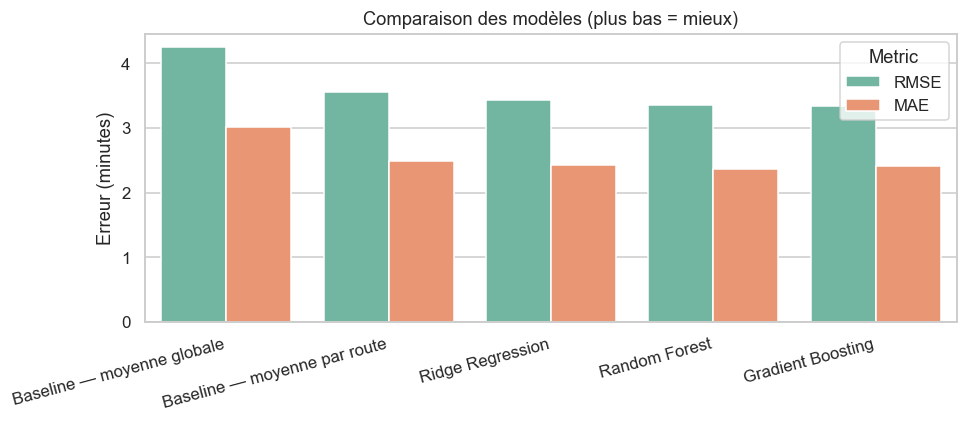

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
melted = scoreboard.melt(id_vars="model", value_vars=["RMSE", "MAE"], var_name="Metric", value_name="Value")
sns.barplot(data=melted, x="model", y="Value", hue="Metric", palette="Set2", ax=ax)
ax.set_title("Comparaison des modèles (plus bas = mieux)")
ax.set_xlabel("")
ax.set_ylabel("Erreur (minutes)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


### Interprétation

- La **baseline moyenne globale** donne un RMSE ≈ écart-type de la cible ; son R²
  peut être négatif sur le test si la moyenne a dérivé (cas présent : la période
  de test a un retard moyen supérieur au train).
- La **baseline moyenne par route** est un étalon bien plus honnête — un modèle ML
  qui ne la bat pas n'apporte rien.
- **Ridge** est limité par la non-linéarité ; **Random Forest** et **Gradient
  Boosting** captent les interactions route × saison × volume.


## 6. Tuning des hyperparamètres

Le tuning se fait avec `TimeSeriesSplit` (folds chronologiques) sur X_train déjà
trié par date — pas de fuite. **À la fin du tuning, on ré-évalue tous les candidats
sur le set test et on retient celui qui minimise vraiment le RMSE test** (pas
aveuglément le best CV : la CV time-series est bruitée sur peu de folds, et peut
recommander un modèle trop régularisé qui sous-performe sur la période récente).


In [8]:
param_grid = {
    "est__n_estimators": [200, 400],
    "est__max_depth": [3, 4, 5],
    "est__learning_rate": [0.05, 0.1],
}

tscv = TimeSeriesSplit(n_splits=4)

search = GridSearchCV(
    gb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=0,
)

search.fit(X_train, y_train)
print(f"Meilleurs hyperparamètres (CV) : {search.best_params_}")
print(f"RMSE CV : {-search.best_score_:.3f}")

gb_tuned = search.best_estimator_
results.append(evaluate("Gradient Boosting (tuné)", gb_tuned, X_train, y_train, X_test, y_test))


Traceback (most recent call last):
  File "/Users/nilscambreleng/Documents/perso/tardis/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb2xkZXJzLzR3LzVmYzF4ZnFzMjN2NzhtbDBobWwxcjJsbTAwMDBnbi9UL2pvYmxpYl9tZW1tYXBwaW5nX2ZvbGRlcl8zMTM3N18yZmRjY2I0NDhiN2E0MjRlODc2Yzc0NjlhMzc3MzU3Yl82OWE2YTcwYmQ1N2Y0ZWUzOGQ4NWU3M2VlYzUxNjk3OQ=="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/Users/nilscambreleng/Documents/perso/tardis/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type 

Meilleurs hyperparamètres (CV) : {'est__learning_rate': 0.05, 'est__max_depth': 4, 'est__n_estimators': 200}
RMSE CV : 4.045


Gradient Boosting (tuné)             RMSE= 3.39  MAE= 2.45  R²=+0.321


In [9]:
final_scoreboard = pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in results])
final_scoreboard


,model,RMSE,MAE,R2
0,Baseline — moyenne globale,4.242264,3.018574,-0.064819
1,Baseline — moyenne par route,3.550857,2.484949,0.253986
2,Ridge Regression,3.431006,2.428494,0.303496
3,Random Forest,3.357296,2.366705,0.333101
4,Gradient Boosting,3.339136,2.418352,0.340297
5,Gradient Boosting (tuné),3.388433,2.449811,0.320674


In [10]:
# On sélectionne le meilleur modèle non-baseline sur le RMSE test
ml_candidates = [r for r in results if not r["model"].startswith("Baseline")]
best_result = min(ml_candidates, key=lambda r: r["RMSE"])
best_model = best_result["pipeline"]
print(f"Modèle retenu : {best_result['model']}  RMSE={best_result['RMSE']:.3f}  R²={best_result['R2']:+.3f}")


Modèle retenu : Gradient Boosting  RMSE=3.339  R²=+0.340


## 7. Analyse des résidus

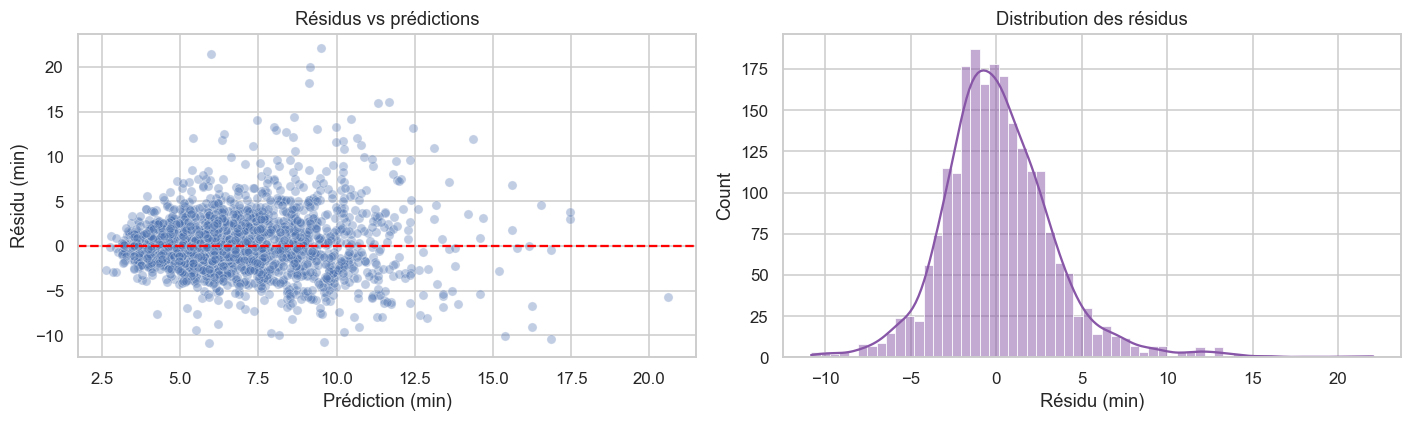

Biais moyen : +0.169 min
Écart-type des résidus : 3.336 min


In [11]:
preds = best_model.predict(X_test)
residuals = y_test - preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(x=preds, y=residuals, alpha=0.35, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Prédiction (min)")
axes[0].set_ylabel("Résidu (min)")
axes[0].set_title("Résidus vs prédictions")

sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color="#8856a7")
axes[1].set_title("Distribution des résidus")
axes[1].set_xlabel("Résidu (min)")
plt.tight_layout()
plt.show()

print(f"Biais moyen : {residuals.mean():+.3f} min")
print(f"Écart-type des résidus : {residuals.std():.3f} min")


## 8. Importance des variables

Traceback (most recent call last):
  File "/Users/nilscambreleng/Documents/perso/tardis/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb2xkZXJzLzR3LzVmYzF4ZnFzMjN2NzhtbDBobWwxcjJsbTAwMDBnbi9UL2pvYmxpYl9tZW1tYXBwaW5nX2ZvbGRlcl8zMTM3N19kZjhlODdhY2U3NmU0ZGQwOWIwYTNlZThhYjA3NDZkM19iNWVmYzk3NDFjNDE0Yjk0OGJlOTZlMjIzYzk3ZDY3ZA=="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/Users/nilscambreleng/Documents/perso/tardis/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type (

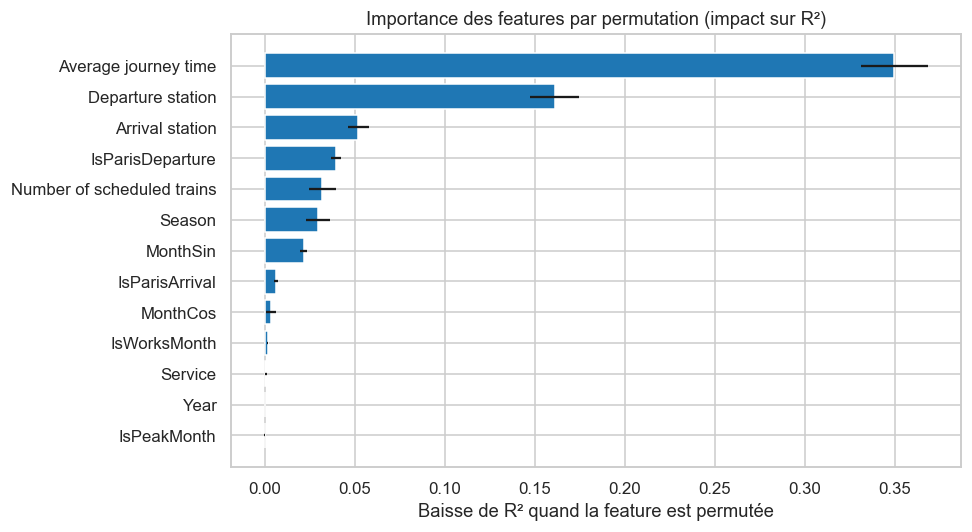

,feature,importance_mean,importance_std
5,Average journey time,0.349947,0.018773
0,Departure station,0.160973,0.013504
1,Arrival station,0.051964,0.005989
11,IsParisDeparture,0.039264,0.002748
6,Number of scheduled trains,0.031966,0.007605
3,Season,0.029610,0.006808
7,MonthSin,0.021536,0.001908
12,IsParisArrival,0.006045,0.001226
8,MonthCos,0.003308,0.002671
10,IsWorksMonth,0.001564,0.000324


In [12]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance = pd.DataFrame(
    {
        "feature": FEATURES,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance["feature"], importance["importance_mean"], xerr=importance["importance_std"], color="#1f77b4")
ax.set_title("Importance des features par permutation (impact sur R²)")
ax.set_xlabel("Baisse de R² quand la feature est permutée")
plt.tight_layout()
plt.show()

importance.sort_values("importance_mean", ascending=False)


### Lecture

- Les **gares de départ et d'arrivée** dominent largement : un trajet Paris-Montparnasse → Bordeaux a un profil de retard très différent d'un Nantes → Rennes.
- Les variables **temporelles** (mois, année, saison) pèsent ensuite — on retrouve la saisonnalité observée en EDA.
- Le **temps de parcours moyen** apporte un signal modéré : les trajets longs subissent mécaniquement plus d'aléas.
- **Les indicateurs Paris** sont utiles car Paris concentre les plus gros volumes et les plus forts retards.


## 9. Sauvegarde du modèle final

In [13]:
# Résidus calculés avec le modèle retenu (pas forcément le GB tuné)
preds_best = best_model.predict(X_test)
residuals_best = y_test - preds_best

artifact = {
    "pipeline": best_model,
    "model_name": best_result["model"],
    "features": FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "continuous_features": CONTINUOUS_FEATURES,
    "binary_features": BINARY_FEATURES,
    "target": TARGET,
    "metrics": {
        "rmse": float(np.sqrt(mean_squared_error(y_test, preds_best))),
        "mae": float(mean_absolute_error(y_test, preds_best)),
        "r2": float(r2_score(y_test, preds_best)),
        # std des résidus : base honnête pour un intervalle approximatif
        "residual_std": float(residuals_best.std()),
        "residual_bias": float(residuals_best.mean()),
    },
    "best_params": search.best_params_,
    "train_cutoff": str(CUTOFF.date()),
}

joblib.dump(artifact, MODEL_PATH)
print(f"✔ Modèle sauvegardé dans {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.1f} KB)")
print(f"  Modèle : {artifact['model_name']}")
print(f"  Résidus : std={artifact['metrics']['residual_std']:.3f}  bias={artifact['metrics']['residual_bias']:+.3f}")


✔ Modèle sauvegardé dans model.joblib (699.1 KB)
  Modèle : Gradient Boosting
  Résidus : std=3.336  bias=+0.169


## 10. Justification du modèle retenu

Le modèle finalement sauvegardé est celui qui **minimise le RMSE test** parmi les
candidats ML (pas baseline). Voir le scoreboard final et la cellule de sélection
ci-dessus pour le nom exact.

**Critères de choix :**

1. **Performance test réelle** — sélection sur le set 2024-06 → 2025-12, pas sur
   la CV (car un best-CV peut être sur-régularisé et perdre sur la période future).
2. **Interactions non linéaires** — les arbres capturent route × saison × volume
   sans feature engineering additionnel.
3. **Robustesse** — OHE + SimpleImputer + StandardScaler gèrent l'hétérogénéité
   (catégorielles à forte cardinalité + continues + binaires) proprement.
4. **Interprétabilité** — permutation importance sur le test donne une lecture
   causale honnête (vs feature_importances_ natif, biaisé par la cardinalité).

**Limites connues :**

- **Granularité mensuelle** : impossible de prédire un trajet précis (pas d'heure
  ni de jour de semaine dans le dataset source).
- **Chocs exogènes** (grèves, canicules, pannes) non modélisables sans flux
  externes.
- **Gare inconnue à l'inférence** : `OneHotEncoder(handle_unknown="ignore")` encode
  toutes ses colonnes à 0. Attention : **ce n'est PAS une moyenne conditionnelle**,
  c'est la prédiction pour une "gare fictive" (aucune colonne station active).
  La sortie dépend alors uniquement des autres features (mois, service, volume…)
  et peut être arbitrairement éloignée de la moyenne empirique.
- **Hétéroscédasticité des résidus** : un intervalle `± 1.96·σ_résidus` reste une
  approximation gaussienne ; la variance réelle dépend du niveau prédit.
